## Voice AI


In [ ]:
import os
import numpy as numpy
import torch
from accelerate import Accelerator
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoFeatureExtractor, set_seed
import librosa
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio, display
from dotenv import load_dotenv
load_dotenv()


In [ ]:
seed = 42
set_seed(seed)
torch.manual_seed(seed)
np.random.seed(seed)   
api_key = os.getenv("gemini_key")
accelerator = Accelerator()
device = accelerator.device
print(f"Using device: {device}")


In [ ]:
import torch
from parler_tts import ParlerTTSForConditionalGeneration
from transformers import AutoTokenizer
import soundfile as sf

device = "cuda:0" if torch.cuda.is_available() else "cpu"

model = ParlerTTSForConditionalGeneration.from_pretrained("parler-tts/parler-tts-mini-v1").to(device)
tokenizer = AutoTokenizer.from_pretrained("parler-tts/parler-tts-mini-v1")

prompt = "Hey, how are you doing today?"
description = "A female speaker delivers a slightly expressive and animated speech with a moderate speed and pitch. The recording is of very high quality, with the speaker's voice sounding clear and very close up."

input_ids = tokenizer(description, return_tensors="pt").input_ids.to(device)
prompt_input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)

generation = model.generate(input_ids=input_ids, prompt_input_ids=prompt_input_ids)
audio_arr = generation.cpu().numpy().squeeze()
sf.write("parler_tts_out.wav", audio_arr, model.config.sampling_rate)

In [ ]:
MODEL_ID = "parler-tts/parler-tts-mini-v1" # The identifier for the Parler-TTS model to load

dtype = torch.bfloat16 if torch.cuda.is_available() or getattr(torch.backends, "mps", None) and torch.backends.mps.is_available() else torch.float32 # Use bfloat16 precision if on supported hardware for faster inference and lower memory usage, otherwise use float32
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID) # Load the tokenizer for the Parler-TTS model
feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_ID) # Includes audio preprocessing config (sr, normalization)

model = ParlerTTSForConditionalGeneration.from_pretrained(
    MODEL_ID, # Hub id pulls config.json + weights (cached locally after first download)
    torch_dtype=dtype # Lowers activation/weight precision to reduce memory usage and speed up inference on supported hardware
) # Load the Parler-TTS model with the specified data type

model = accelerator.prepare(model) # Prepare the model for efficient inference with the accelerator
model.eval() # Set the model to evaluation mode (disables dropout, etc.)

sampling_rate = feature_extractor.sampling_rate # Get the sampling rate expected by the model from the feature extractor config
print(f"Model sampling rate: {sampling_rate} Hz") # Print the model's expected sampling rate

prompt_text = "Welcome to the neural text to speech pipeline. You are hearing Parler TTS generate this audio from text." # The text prompt to convert to speech
description = "Jon speaks clearly with moderate pitch and speed in a quiet room with close-mic presence"

inputs = tokenizer(description, return_tensors="pt", padding=True) # Tokenize the input text and move tensors to the appropriate device
inputs = {k: v.to(device) for k, v in inputs.items()} # Move input tensors to the same device as the model

prompt = tokenizer(prompt_text, return_tensors="pt", padding=True) # Tokenize the prompt text and move tensors to the appropriate device
prompt = {k: v.to(device) for k, v in prompt.items()} # Move prompt tensors to the same device as the model

with torch.inference_mode():
    generation = model.generate(
        input_ids = inputs["input_ids"], # The tokenized input text to condition the TTS generation
        attention_mask = inputs["attention_mask"], # Attention mask for the input text
        prompt_input_ids = prompt["input_ids"], # The tokenized prompt text to guide the TTS generation
        prompt_attention_mask = prompt["attention_mask"], # Attention mask for the prompt text
        do_sample=True, # Enable sampling for more varied outputs
        temperature=0.7, # Set the temperature for sampling (higher values = more random)
        return_dict_in_generate=True, # Return a dictionary with generation outputs
    )

# Extract the first and only waveform from the batch using the reported audio length (avoids padding tail)
seq_lens = getattr(generation, "sequences_lengths", None)
if seq_lens is None:
    seq_lens = getattr(generation, "sequence_lengths", None)

audio_tensor = generation.sequences[0, :seq_lens[0]] if seq_lens is not None else generation.sequences[0]

# Move to CPU NumPy for librosa/IPython
audio_np = audio_tensor.cpu().numpy().squeeze() # removes singleton dimension, resulting in a 1D array of audio samples

print("audio_np.shape: ", audio_np.shape, "duration_s: ", float(len(audio_np)) / float(sampling_rate)) # Print the shape of the generated audio NumPy array
display(Audio(audio_np, rate=sampling_rate)) # Display the generated audio in the Jupyter notebook with the correct sampling rate



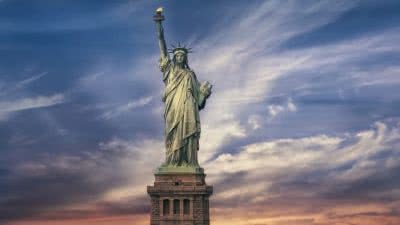

Generated caption:  The landmark prominently featured in the image is the **Statue of Liberty**, officially known as **Liberty Enlightening the World**.

**Location:**
It is situated on **Liberty Island** in **New York Harbor**, New York City, United States. Its strategic position makes it a striking sight for all approaching the city by sea.

**Notable Features and Detailed Description:**

1.  **The Figure of Liberty:** The statue depicts a robed female figure, personifying Libertas, the Roman goddess of liberty. She stands majestically, facing eastward toward the Atlantic Ocean, her posture conveying a sense of strength and serenity.

2.  **The Torch:** Her most prominent feature is her right arm, raised high above her head, grasping a torch. In the image, the torch appears to have a golden or yellow flame, symbolizing enlightenment, progress, and guiding light. This torch was originally designed to be a functional lighthouse.

3.  **The Tablet:** In her left arm, held lower and clos

In [12]:
import google.generativeai as genai
from PIL import Image
Landmark_image_path = os.path.join(os.getcwd(), "landmark.jpg")
def load_landmark_image(image_path):
    image = Image.open(image_path)
    return image
pil_image = load_landmark_image(Landmark_image_path)
display(pil_image)
if not api_key:
    print("API key not found. Please set the 'gemini_key' environment variable.")
    caption  = "A photo of a famous landmark, the Eiffel Tower in Paris, France, taken during the day with a clear blue sky in the background."
else:
    genai.configure(api_key=api_key)
    gemini_vision_model = os.environ.get("gemini_vision_model", "gemini-2.5-flash") # Use the specified Gemini Vision model or default to "gemini-1.5-pro"
    model = genai.GenerativeModel(gemini_vision_model) # Initialize the Gemini Vision model
    vision_prompt = f"Describe the landmark in this image in detail, including its name, location, and any notable features. Be as descriptive as possible."
    response = model.generate_content([vision_prompt, pil_image])
    caption = response.text
print("Generated caption: ", caption)